In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Thesis")
EXP_DIR = BASE_DIR / "Structural_MorphBPE_Experiment"

DATA_DIR = EXP_DIR / "data"
MODEL_DIR = EXP_DIR / "models"
RESULT_DIR = EXP_DIR / "results"
LOG_DIR = EXP_DIR / "logs"

for directory in [DATA_DIR, MODEL_DIR, RESULT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Experiment directory:", EXP_DIR)

Experiment directory: /content/drive/MyDrive/Thesis/Structural_MorphBPE_Experiment


In [3]:
# Cell 1: Setup & Dependencies
import unicodedata
import json
from typing import List, Tuple, Dict, Set
from collections import defaultdict

print("Environment ready for MorphBPE execution.")

Environment ready for MorphBPE execution.


In [4]:
# Cell 2: Unitization & Ingestion

IGBO_DIGRAPHS = {
    "ch", "gb", "gh", "gw", "kp", "kw", "nw", "ny", "sh",
    "Ch", "Gb", "Gh", "Gw", "Kp", "Kw", "Nw", "Ny", "Sh",
    "CH", "GB", "GH", "GW", "KP", "KW", "NW", "NY", "SH"
}

def unitize_morpheme(morpheme: str) -> Tuple[str, ...]:
    """
    Normalizes morphemes to Unicode NFC and segments into atomic units:
    either standard Igbo digraphs or single code points (preserving sub-dots/accents).
    """
    norm_m = unicodedata.normalize("NFC", morpheme)
    units: List[str] = []
    i = 0
    n = len(norm_m)

    while i < n:
        if i + 1 < n and norm_m[i:i+2] in IGBO_DIGRAPHS:
            units.append(norm_m[i:i+2])
            i += 2
        else:
            units.append(norm_m[i])
            i += 1

    return tuple(units)

def parse_segmented_word(morphemes: List[str]) -> Tuple[Tuple[str, ...], ...]:
    """Converts a list of morpheme strings into nested tuples of atomic units."""
    return tuple(unitize_morpheme(m) for m in morphemes if m)

def build_morph_corpus(raw_data: List[List[List[str]]]) -> Dict[Tuple[Tuple[str, ...], ...], int]:
    """Converts raw segmented data rows into weighted WordTuple frequencies."""
    corpus_freqs = defaultdict(int)
    for word_morphemes_char_lists in raw_data:
        morpheme_strings = ["".join(char_list) for char_list in word_morphemes_char_lists]
        word_tuple = parse_segmented_word(morpheme_strings)
        if word_tuple:
            corpus_freqs[word_tuple] += 1
    return dict(corpus_freqs)

In [5]:
# Cell 3: Constrained MorphBPE Engine

WordTuple = Tuple[Tuple[str, ...], ...]

class MorphBPETrainer:
    def __init__(self, special_tokens: List[str] = None):
        self.special_tokens = special_tokens or ["<s>", "<pad>", "</s>", "<unk>", "<mask Diego>"]
        self.merges: List[Tuple[str, str]] = []
        self.vocab: Dict[str, int] = {}

    def _count_pairs(self, corpus: Dict[WordTuple, int]) -> Dict[Tuple[str, str], int]:
        """Counts bigrams strictly WITHIN each morpheme boundary."""
        pair_counts = defaultdict(int)
        for word_tuple, freq in corpus.items():
            for morpheme in word_tuple:
                for i in range(len(morpheme) - 1):
                    pair = (morpheme[i], morpheme[i + 1])
                    pair_counts[pair] += freq
        return pair_counts

    def _apply_merge_to_morpheme(self, morpheme: Tuple[str, ...], pair: Tuple[str, str]) -> Tuple[str, ...]:
        first, second = pair
        merged = first + second
        new_morpheme = []
        i = 0
        n = len(morpheme)

        while i < n:
            if i < n - 1 and morpheme[i] == first and morpheme[i + 1] == second:
                new_morpheme.append(merged)
                i += 2
            else:
                new_morpheme.append(morpheme[i])
                i += 1

        return tuple(new_morpheme)

    def _apply_merge_to_corpus(self, corpus: Dict[WordTuple, int], pair: Tuple[str, str]) -> Dict[WordTuple, int]:
        new_corpus = {}
        for word_tuple, freq in corpus.items():
            new_word = tuple(self._apply_merge_to_morpheme(m, pair) for m in word_tuple)
            new_corpus[new_word] = freq
        return new_corpus

    def train(self, corpus: Dict[WordTuple, int], num_merges: int, verbose: bool = True):
        # 1. Initialize V_0
        initial_units = set()
        for word_tuple in corpus.keys():
            for morpheme in word_tuple:
                for unit in morpheme:
                    initial_units.add(unit)

        current_vocab = list(self.special_tokens) + sorted(list(initial_units))
        self.vocab = {token: idx for idx, token in enumerate(current_vocab)}
        current_corpus = corpus

        # 2. Iterative merge learning
        for step in range(1, num_merges + 1):
            pair_counts = self._count_pairs(current_corpus)
            if not pair_counts:
                if verbose:
                    print(f"Stopping early at step {step}: No remaining intra-morpheme pairs.")
                break

            best_pair = max(pair_counts, key=pair_counts.get)
            count = pair_counts[best_pair]

            if count <= 1:
                if verbose:
                    print(f"Stopping early at step {step}: Best pair count <= 1.")
                break

            self.merges.append(best_pair)
            merged_token = best_pair[0] + best_pair[1]
            if merged_token not in self.vocab:
                self.vocab[merged_token] = len(self.vocab)

            if verbose:
                print(f"Merge {step:02d}: {best_pair} -> '{merged_token}' (frequency: {count})")

            current_corpus = self._apply_merge_to_corpus(current_corpus, best_pair)

    def export_merges(self, filepath: str):
        with open(filepath, "w", encoding="utf-8") as f:
            f.write("#version: 0.2\n")
            for pair in self.merges:
                f.write(f"{pair[0]} {pair[1]}\n")

    def export_vocab(self, filepath: str):
        with open(filepath, "w", encoding="utf-8") as f:
            json.dump(self.vocab, f, ensure_ascii=False, indent=2)

In [14]:
import json
import logging
from pathlib import Path
import matplotlib.pyplot as plt
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers

# ---------------------------------------------------------
# 1. Directory & Logging Setup
# ---------------------------------------------------------
BASE_DIR = Path("/content/drive/MyDrive/Thesis")
EXP_DIR = BASE_DIR / "Structural_MorphBPE_Experiment"

DATA_DIR = EXP_DIR / "data"
MODEL_DIR = EXP_DIR / "models"
RESULT_DIR = EXP_DIR / "results"
LOG_DIR = EXP_DIR / "logs"

for directory in [DATA_DIR, MODEL_DIR, RESULT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=LOG_DIR / "morph_bpe_training.log",
    filemode="a",
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO
)
logger = logging.getLogger(__name__)
print(f"Directories initialized. Base experiment path: {EXP_DIR}")

# ---------------------------------------------------------
# 2. Morphological Boundary Injection
# ---------------------------------------------------------
INPUT_JSON_PATH =  Path("/content/igbo_morph_scoped_corpus.json") # Corrected path
INJECTED_CORPUS_TXT = DATA_DIR / "igbo_boundary_injected_corpus.txt"
RAW_CORPUS_TXT = DATA_DIR / "igbo_raw_corpus.txt"

# Delimiter used to mark sub-word morphological segments
MORPH_BOUNDARY_MARKER = "@@"

def inject_morphological_boundaries(json_path: Path, injected_out: Path, raw_out: Path):
    """
    Parses segmentations from the corpus and formats data for BPE training.
    Expected JSON schema variants:
      - List of dicts: [{"text": "...", "segments": ["ọ", "chọ", "rọ"]}]
      - Dict mapping: {"sentence_id": {"segmented_tokens": [...]}}
      - Dict mapping (user-provided): {"word": [["char", ...], ["char", ...]]}
      - List of List[List[str]]: [[["S","o","w","o","r","e"]], [["R","e","v","o","l","u","t","i","o","n"]], ...]
    """
    print(f"Loading corpus from: {json_path}")
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    injected_lines = []
    raw_lines = []

    if isinstance(data, dict):
        # Check for user-provided format: {"word": [["char", ...], ["char", ...]]}
        all_values_are_lists_of_lists = all(
            isinstance(v, list) and all(isinstance(sub_v, list) for sub_v in v)
            for v in data.values()
        )
        if all_values_are_lists_of_lists:
            for word, segmented_morphemes_char_lists in data.items():
                processed_morphemes = []
                for char_list in segmented_morphemes_char_lists:
                    processed_morphemes.append("".join(char_list))
                injected_lines.append(f"{MORPH_BOUNDARY_MARKER} ".join(processed_morphemes))
                raw_lines.append(word) # Original word for raw text
        else:
            # Original "Dict mapping" format: {"sentence_id": {"segmented_tokens": [...]}}
            for item in data.values():
                if isinstance(item, dict):
                    if "segmented_text" in item:
                        injected_lines.append(item["segmented_text"])
                    elif "tokens" in item and isinstance(item["tokens"], list):
                        line_tokens = []
                        for tok in item["tokens"]:
                            if isinstance(tok, list):
                                line_tokens.append(f"{MORPH_BOUNDARY_MARKER} ".join(tok))
                            else:
                                line_tokens.append(str(tok))
                        injected_lines.append(" ".join(line_tokens))
                    elif "text" in item:
                        raw_lines.append(item["text"])
                elif isinstance(item, str):
                    raw_lines.append(item)
    elif isinstance(data, list):
        # Check for user-provided format: List[List[List[str]]] e.g., [[["S", "o", "w", "o", "r", "e"]], [["R", "e", "v", "o", "l", "u", "t", "i", "o", "n"]], ...]
        if all(isinstance(item, list) and all(isinstance(sub_item, list) for sub_item in item) for item in data):
            for word_segments_char_lists in data: # word_segments_char_lists is like [["n", "g", "a", "g", "h", "a", "r", "ị"], ["i", "w", "e"]]
                processed_morphemes = []
                full_word_chars = []
                for morpheme_char_list in word_segments_char_lists: # morpheme_char_list is like ["n", "g", "a", "g", "h", "a", "r", "ị"]
                    morpheme_str = "".join(morpheme_char_list)
                    processed_morphemes.append(morpheme_str)
                    full_word_chars.extend(morpheme_char_list)
                injected_lines.append(f"{MORPH_BOUNDARY_MARKER} ".join(processed_morphemes))
                raw_lines.append("".join(full_word_chars))
        else:
            # Original "List of dicts" format: [{"text": "...", "segments": ["ọ", "chọ", "rọ"]}]
            for item in data:
                if isinstance(item, dict):
                    if "segmented_text" in item:
                        injected_lines.append(item["segmented_text"])
                    elif "tokens" in item and isinstance(item["tokens"], list):
                        line_tokens = []
                        for tok in item["tokens"]:
                            if isinstance(tok, list):
                                line_tokens.append(f"{MORPH_BOUNDARY_MARKER} ".join(tok))
                            else:
                                line_tokens.append(str(tok))
                        injected_lines.append(" ".join(line_tokens))
                    elif "text" in item:
                        raw_lines.append(item["text"])
                elif isinstance(item, str):
                    raw_lines.append(item)

    # Write boundary-injected corpus
    if injected_lines:
        with open(injected_out, "w", encoding="utf-8") as f:
            f.write("\n".join(injected_lines))
        print(f"Saved boundary-injected corpus ({len(injected_lines)} lines) to {injected_out}")
    else:
        print("Warning: No injected lines generated. Check JSON format.")

    # Fallback/Raw output writing if raw segments exist
    if raw_lines:
        with open(raw_out, "w", encoding="utf-8") as f:
            f.write("\n".join(raw_lines))
        print(f"Saved raw text fallback ({len(raw_lines)} lines) to {raw_out}")
    else:
        print("Warning: No raw lines generated. Check JSON format.")

inject_morphological_boundaries(INPUT_JSON_PATH, INJECTED_CORPUS_TXT, RAW_CORPUS_TXT)

Directories initialized. Base experiment path: /content/drive/MyDrive/Thesis/Structural_MorphBPE_Experiment
Loading corpus from: /content/igbo_morph_scoped_corpus.json
Saved boundary-injected corpus (833843 lines) to /content/drive/MyDrive/Thesis/Structural_MorphBPE_Experiment/data/igbo_boundary_injected_corpus.txt
Saved raw text fallback (833843 lines) to /content/drive/MyDrive/Thesis/Structural_MorphBPE_Experiment/data/igbo_raw_corpus.txt



Starting MorphBPE Training Grid...
Target:  2000 | Actual:  2000 | Fertility: 1.75 sub-tokens/word | Char tokens: 203
Target:  4000 | Actual:  4000 | Fertility: 1.62 sub-tokens/word | Char tokens: 203
Target:  8000 | Actual:  8000 | Fertility: 1.62 sub-tokens/word | Char tokens: 203
Target: 12000 | Actual: 12000 | Fertility: 1.62 sub-tokens/word | Char tokens: 203
Target: 16000 | Actual: 16000 | Fertility: 1.62 sub-tokens/word | Char tokens: 203


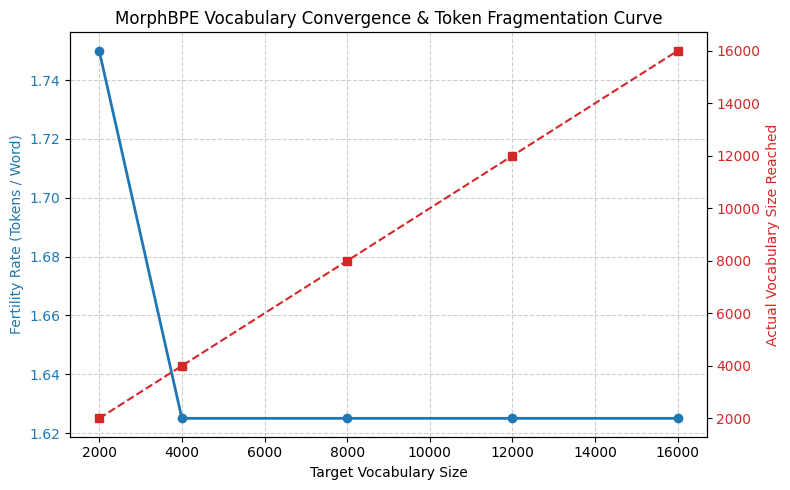


Artifacts saved successfully in:
 - Models: /content/drive/MyDrive/Thesis/Structural_MorphBPE_Experiment/models
 - Diagnostics: /content/drive/MyDrive/Thesis/Structural_MorphBPE_Experiment/results


In [15]:
# ---------------------------------------------------------
# 3. Model Training & Convergence Sweep
# ---------------------------------------------------------
TARGET_VOCAB_SIZES = [2000, 4000, 8000, 12000, 16000]
SPECIAL_TOKENS = ["<unk>", "<s>", "</s>", "<pad>", "<mask morph>"]

convergence_metrics = {
    "target_vocab": [],
    "actual_vocab": [],
    "fertility_rate": [],
    "oov_char_tokens": []
}

# Test sample for evaluating tokenization fertility/fragmentation
EVAL_SENTENCE = "Onye ọ bụla nwere ikike ịnweta agụmakwụkwọ n'efu."

print("\nStarting MorphBPE Training Grid...")

for target_v in TARGET_VOCAB_SIZES:
    tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))

    # Ensure standard unicode normalization preserving sub-dots & diacritics
    tokenizer.normalizer = normalizers.Sequence([
        normalizers.NFC()
    ])

    # Pre-tokenizer splits on whitespace and preserves boundary markers
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    trainer = trainers.BpeTrainer(
        vocab_size=target_v,
        special_tokens=SPECIAL_TOKENS,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
        show_progress=False
    )

    train_file = str(INJECTED_CORPUS_TXT if INJECTED_CORPUS_TXT.exists() else RAW_CORPUS_TXT)
    tokenizer.train(files=[train_file], trainer=trainer)

    # Save model artifacts
    save_path = MODEL_DIR / f"morph_bpe_{target_v}.json"
    tokenizer.save(str(save_path))

    actual_v = tokenizer.get_vocab_size()

    # Measure fertility rate (average sub-tokens per evaluation sentence)
    encoded = tokenizer.encode(EVAL_SENTENCE)
    fertility = len(encoded.tokens) / len(EVAL_SENTENCE.split())

    # Count isolated single-character tokens (excluding special characters)
    single_chars = sum(1 for tok in tokenizer.get_vocab().keys() if len(tok) == 1 and tok.isalpha())

    convergence_metrics["target_vocab"].append(target_v)
    convergence_metrics["actual_vocab"].append(actual_v)
    convergence_metrics["fertility_rate"].append(fertility)
    convergence_metrics["oov_char_tokens"].append(single_chars)

    print(f"Target: {target_v:5d} | Actual: {actual_v:5d} | Fertility: {fertility:.2f} sub-tokens/word | Char tokens: {single_chars}")

# ---------------------------------------------------------
# 4. Convergence Analysis & Metric Visualization
# ---------------------------------------------------------
# Save numerical results
with open(RESULT_DIR / "morph_bpe_convergence.json", "w", encoding="utf-8") as f:
    json.dump(convergence_metrics, f, indent=2)

# Generate Convergence Diagnostic Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

color = "tab:blue"
ax1.set_xlabel("Target Vocabulary Size")
ax1.set_ylabel("Fertility Rate (Tokens / Word)", color=color)
ax1.plot(convergence_metrics["target_vocab"], convergence_metrics["fertility_rate"], marker="o", color=color, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.6)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Actual Vocabulary Size Reached", color=color)
ax2.plot(convergence_metrics["target_vocab"], convergence_metrics["actual_vocab"], marker="s", linestyle="--", color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("MorphBPE Vocabulary Convergence & Token Fragmentation Curve")
plt.tight_layout()
plt.savefig(RESULT_DIR / "morph_bpe_convergence_curve.png", dpi=300)
plt.show()

print(f"\nArtifacts saved successfully in:\n - Models: {MODEL_DIR}\n - Diagnostics: {RESULT_DIR}")